In [23]:
from pathlib import Path
root = Path(r"E:\code\PycharmProjects\pythonProject\pytorch\data\dsb2018\stage1_train")
case_dirs = sorted(root.iterdir())
print("Number of cases:", len(case_dirs))
print("the first case:", case_dirs[0])

Number of cases: 670
the first case: E:\code\PycharmProjects\pythonProject\pytorch\data\dsb2018\stage1_train\00071198d059ba7f5914a526d124d28e6d010c92466da21d4a04cd5413362552


In [32]:
from PIL import Image
import numpy as np

case_dir = case_dirs[0]
image_path = next((case_dir / "images").glob("*.png"))
# print("image_path:", image_path)
# Image.open(image_path).convert("RGB")
image = np.array(Image.open(image_path).convert("RGB"))
print("image shape:", image.shape)
print("image dtype:", image.dtype)
print("range of pixel values:", image.min(), image.max())

image shape: (256, 256, 3)
image dtype: uint8
range of pixel values: 1 108


In [33]:
mask_paths = sorted((case_dir / "masks").glob("*.png"))
print("Number of masks:", len(mask_paths))
mask = np.zeros(image.shape[:2], dtype=np.uint8)
for mask_path in mask_paths:
    one = np.array(Image.open(mask_path).convert("L"))
    mask = np.maximum(mask, one)
print("mask shape:", mask.shape)
print("merged mask range of pixel values:", np.unique(mask))
mask_bin = (mask > 127).astype(np.uint8)
print("前景占比: {:.2%}".format(mask_bin.mean()))

Number of masks: 27
mask shape: (256, 256)
merged mask range of pixel values: [  0 255]
前景占比: 8.72%


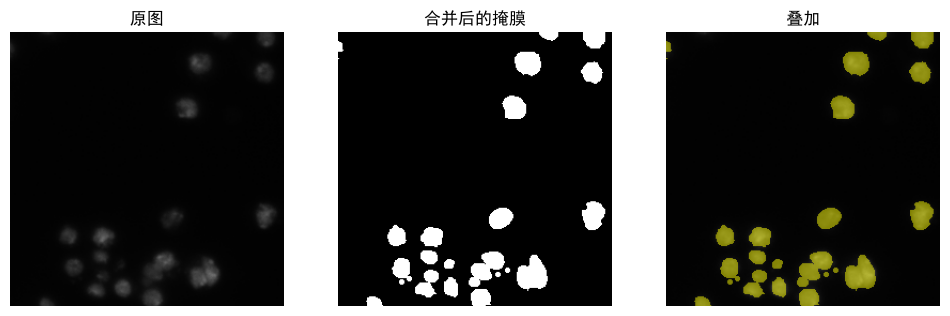

In [29]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']  # Windows 用黑体
plt.rcParams['axes.unicode_minus'] = False    # 正常显示负号
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(image)
plt.title("原图")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask_bin, cmap="gray")
plt.title("合并后的掩膜")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(image)
plt.imshow(np.ma.masked_where(mask_bin == 0, mask_bin), alpha=0.5, cmap="autumn", vmin=0, vmax=1)
plt.title("叠加")
plt.axis("off")

plt.show()

In [25]:
records = []

for case_dir in case_dirs:
    image_path = next((case_dir / "images").glob("*.png"))
    width, height = Image.open(image_path).size      # PIL 的 size 是 (宽, 高)

    mask_paths = sorted((case_dir / "masks").glob("*.png"))
    merged = np.zeros((height, width), dtype=np.uint8)
    for mask_path in mask_paths:
        one = np.array(Image.open(mask_path).convert("L"))
        merged = np.maximum(merged, one)

    records.append({
        "case": case_dir.name,
        "width": width,
        "height": height,
        "n_masks": len(mask_paths),
        "fg_ratio": float((merged > 127).mean()),
    })

widths = [r["width"] for r in records]
heights = [r["height"] for r in records]
n_masks = [r["n_masks"] for r in records]
fg = [r["fg_ratio"] for r in records]

print("样本数:", len(records))
print("宽度范围: {} ~ {}".format(min(widths), max(widths)))
print("高度范围: {} ~ {}".format(min(heights), max(heights)))
print("掩膜数量: 最少 {}，最多 {}，平均 {:.1f}".format(min(n_masks), max(n_masks), sum(n_masks) / len(n_masks)))
print("前景占比: 最小 {:.2%}，最大 {:.2%}，平均 {:.2%}".format(min(fg), max(fg), sum(fg) / len(fg)))

样本数: 670
宽度范围: 256 ~ 1388
高度范围: 256 ~ 1040
掩膜数量: 最少 1，最多 375，平均 44.0
前景占比: 最小 0.03%，最大 59.20%，平均 13.92%
